## Welcome to your notebook.


#### Run this cell to connect to your GIS and get started:

#### Now you are ready to start!

In [1]:
# imports
import urllib, xml.etree.ElementTree as ET, pandas as pd, arcgis

In [2]:
# Load tabledata from the website
# JSON-Response to the url-request for the parking lot data
with urllib.request.urlopen("https://www.bcp-bonn.de/stellplatz/bcpext.xml") as response:
    xml_data = response.read()
xml_data


b'<?xml version="1.0" encoding="iso-8859-1"?>\r\n<parkhaeuser xmlns:msdata="urn:schemas-microsoft-com:xml-msdata" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance">\r\n  <parkhaus>\r\n    <lfdnr>1</lfdnr>\r\n    <bezeichnung>beethoven</bezeichnung>\r\n    <gesamt>416</gesamt>\r\n    <frei>295</frei>\r\n    <status>0</status>\r\n    <zeitstempel>20.07.2026 23:46</zeitstempel>\r\n    <tendenz>3</tendenz>\r\n  </parkhaus>\r\n  <parkhaus>\r\n    <lfdnr>2</lfdnr>\r\n    <bezeichnung>beetplatz</bezeichnung>\r\n    <gesamt>200</gesamt>\r\n    <frei>058</frei>\r\n    <status>0</status>\r\n    <zeitstempel>20.07.2026 23:46</zeitstempel>\r\n    <tendenz>3</tendenz>\r\n  </parkhaus>\r\n  <parkhaus>\r\n    <lfdnr>3</lfdnr>\r\n    <bezeichnung>friedensplatz</bezeichnung>\r\n    <gesamt>810</gesamt>\r\n    <frei>642</frei>\r\n    <status>0</status>\r\n    <zeitstempel>20.07.2026 23:46</zeitstempel>\r\n    <tendenz>3</tendenz>\r\n  </parkhaus>\r\n  <parkhaus>\r\n    <lfdnr>4</lfdnr>\r\n    <bezei

In [4]:
# parse xml as table
parkinglots = []
# Parse the XML data
root = ET.fromstring(xml_data)
len(root)

14

In [5]:
# Access elements
for plot in root.findall('parkhaus'):
    name = plot.find('bezeichnung').text
    total = plot.find('gesamt').text
    free = plot.find('frei').text

    print(f"name: {name}, free: {free}, total: {total}")
    parkinglots.append([name,free,total])
parkinglots

name: beethoven, free: 295, total: 416
name: beetplatz, free: 058, total: 200
name: friedensplatz, free: 642, total: 810
name: karstadt, free: 000, total: 99
name: markt, free: 262, total: 287
name: muensterplatz, free: 314, total: 312
name: operngarage, free: 345, total: 380
name: Rabinstrasse, free: 200, total: 305
name: rheinaue, free: 220, total: 240
name: stadthaus, free: 237, total: 320
name: stadthaus_unten, free: 000, total: 360
name: unigarage, free: 319, total: 438
name: hauptbahnhof, free: 060, total: 94
name: bike_ride, free: 148, total: 220


[['beethoven', '295', '416'],
 ['beetplatz', '058', '200'],
 ['friedensplatz', '642', '810'],
 ['karstadt', '000', '99'],
 ['markt', '262', '287'],
 ['muensterplatz', '314', '312'],
 ['operngarage', '345', '380'],
 ['Rabinstrasse', '200', '305'],
 ['rheinaue', '220', '240'],
 ['stadthaus', '237', '320'],
 ['stadthaus_unten', '000', '360'],
 ['unigarage', '319', '438'],
 ['hauptbahnhof', '060', '94'],
 ['bike_ride', '148', '220']]

In [6]:
# table
df_parkinglotdata = pd.DataFrame(parkinglots, columns = ['name', 'parkingfree', 'parkingtotal'])
df_parkinglotdata

,name,parkingfree,parkingtotal
0,beethoven,295,416
1,beetplatz,058,200
2,friedensplatz,642,810
3,karstadt,000,99
4,markt,262,287
5,muensterplatz,314,312
6,operngarage,345,380
7,Rabinstrasse,200,305
8,rheinaue,220,240
9,stadthaus,237,320


In [7]:
df_parkinglotdata.dtypes

name            str
parkingfree     str
parkingtotal    str
dtype: object

In [8]:
# create and calculate new fields
# turning "parkingtotal" from string into number
df_parkinglotdata['parkingtotal'] = pd.to_numeric(df_parkinglotdata['parkingtotal'])
df_parkinglotdata['parkingfree'] = pd.to_numeric(df_parkinglotdata['parkingfree'])
# fill new field 
df_parkinglotdata["occupancy_in_percent"] = 100 - (df_parkinglotdata["parkingfree"] / df_parkinglotdata["parkingtotal"] * 100)
df_parkinglotdata

,name,parkingfree,parkingtotal,occupancy_in_percent
0,beethoven,295,416,29.086538
1,beetplatz,58,200,71.000000
2,friedensplatz,642,810,20.740741
3,karstadt,0,99,100.000000
4,markt,262,287,8.710801
5,muensterplatz,314,312,-0.641026
6,operngarage,345,380,9.210526
7,Rabinstrasse,200,305,34.426230
8,rheinaue,220,240,8.333333
9,stadthaus,237,320,25.937500


In [9]:
# prepare table for AGOL
# Changing the 'Dataframe' into a Feature Set
fset = arcgis.features.FeatureSet.from_dataframe(df_parkinglotdata)
fset

<FeatureSet> 14 features

In [10]:
# log into arcgis online
from arcgis.gis import GIS
gis = GIS("home")

<Item title:"exercise_13_table1" type:Table Layer owner:cgraeber_digicarto23>
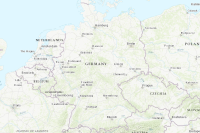

In [11]:
# language of the Target.Feature.Services
live_parkinglotdata_bonn_table = gis.content.get("5a80663d43b349b99da958a8d69758b0")
live_parkinglotdata_bonn_table

In [12]:
# update table on AGOL
# inclusion of the Features into the Feature-Set in the Target-Feature-Services
live_parkinglotdata_bonn_table.tables[0].edit_features(adds=fset)

{'addResults': [{'objectId': 15,
   'uniqueId': 15,
   'globalId': None,
   'success': True},
  {'objectId': 16, 'uniqueId': 16, 'globalId': None, 'success': True},
  {'objectId': 17, 'uniqueId': 17, 'globalId': None, 'success': True},
  {'objectId': 18, 'uniqueId': 18, 'globalId': None, 'success': True},
  {'objectId': 19, 'uniqueId': 19, 'globalId': None, 'success': True},
  {'objectId': 20, 'uniqueId': 20, 'globalId': None, 'success': True},
  {'objectId': 21, 'uniqueId': 21, 'globalId': None, 'success': True},
  {'objectId': 22, 'uniqueId': 22, 'globalId': None, 'success': True},
  {'objectId': 23, 'uniqueId': 23, 'globalId': None, 'success': True},
  {'objectId': 24, 'uniqueId': 24, 'globalId': None, 'success': True},
  {'objectId': 25, 'uniqueId': 25, 'globalId': None, 'success': True},
  {'objectId': 26, 'uniqueId': 26, 'globalId': None, 'success': True},
  {'objectId': 27, 'uniqueId': 27, 'globalId': None, 'success': True},
  {'objectId': 28, 'uniqueId': 28, 'globalId': None, '